In [1]:
%pip install -q statsmodels scipy pyarrow


Note: you may need to restart the kernel to use updated packages.


# Notebook 03 — Korrelationsmodellierung: Sentiment × Kursrenditen

Dieses Notebook beantwortet die Kernfrage des Web-Mining-Projekts:

> **Geht sozialen Medien-Sentiment den Kursrenditen voraus, folgt er ihnen, oder ist der Zusammenhang zufällig?**

| Methode | Fragestellung |
|---------|---------------|
| Pearson / Spearman (Lag 0–3) | Linearer Zusammenhang Sentiment ↔ Rendite |
| Rolling-Korrelation (30 Tage) | Stabilität des Zusammenhangs über Zeit |
| Granger-Kausalitätstest | Trägt Sentiment Vorhersageinformation über Renditen? |
| Event-Study (±5 Handelstage) | Renditemuster um extreme Sentiment-Tage |

**Primär-Input:** `daily_sentiment_original.parquet`, `prices.csv`  
**Sekundär-Input:** Retweet-Dataset bleibt in diesem Notebook bewusst ungenutzt.  
**Outputs:** `correlation_results.parquet`, `granger_results.parquet`, `event_study_results.parquet`, `overlap_report.parquet`


In [2]:
# ---------------------------------------------------------------------------
# Setup
# ---------------------------------------------------------------------------
import warnings
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import grangercausalitytests, adfuller
from statsmodels.stats.multitest import multipletests
import yfinance as yf

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*maxlag.*")
logging.getLogger("statsmodels").setLevel(logging.ERROR)

# ── Paths ────────────────────────────────────────────────────────────────────
ROOT = Path("..")
DAILY_PATH = ROOT / "data" / "processed" / "daily_sentiment_original.parquet"
PRICES_PATH = ROOT / "data" / "raw" / "prices" / "prices.csv"
OUT_DIR = ROOT / "data" / "processed"
OVERLAP_OUT_PATH = OUT_DIR / "overlap_report.parquet"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Figure export ────────────────────────────────────────────────────────────
SAVE_FIGURES = True
FIG_DPI = 300
FIG_DIR = ROOT / "report" / "figures" / "03_correlation_modeling"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def _save_fig(filename: str) -> None:
    if not SAVE_FIGURES:
        return
    out_path = FIG_DIR / filename
    plt.savefig(out_path, dpi=FIG_DPI, bbox_inches="tight")
    print(f"Saved figure -> {out_path}")

# ── Style ────────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.0)
plt.rcParams["figure.dpi"] = 110

# ── Analysis thresholds (method-specific, no global ticker exclusion) ───────
CORR_MIN_OBS = 5
ROLL_WIN = 30
ROLL_MIN = 10
GRANGER_MIN = 30
MAXLAG = 3
WINDOW = 5
SPIKE_STD = 1.0
EVENT_MIN = 5
EVENT_BASE_MIN_ROWS = 20

print("Paths OK:", DAILY_PATH.exists(), PRICES_PATH.exists())
print(f"Primary input: {DAILY_PATH.name}")
print(
    "Thresholds:",
    f"corr>={CORR_MIN_OBS}, roll>={ROLL_WIN}, granger>={GRANGER_MIN},",
    f"event_rows>={EVENT_BASE_MIN_ROWS}, event_count>={EVENT_MIN}",
)
print(f"Figure export: {'ON' if SAVE_FIGURES else 'OFF'} -> {FIG_DIR}")


Paths OK: True True
Primary input: daily_sentiment_original.parquet
Thresholds: corr>=5, roll>=30, granger>=30, event_rows>=20, event_count>=5
Figure export: ON -> ../report/figures/03_correlation_modeling


## 1 — Daten laden & vorbereiten


In [3]:
# ---------------------------------------------------------------------------
# 1a. Sentiment laden
# ---------------------------------------------------------------------------
daily = pd.read_parquet(DAILY_PATH)
daily["date"] = pd.to_datetime(daily["date"])

# sentiment signal: bevorzuge weighted_xlm_compound (Follower-gewichtet)
SENT_COL = "weighted_xlm_compound"

print(f"Daily sentiment: {daily.shape}  |  Tickers: {daily['focus_ticker'].nunique()}")
print(f"Quelle: {DAILY_PATH.name}")
print(
    daily.groupby("focus_ticker")["date"].agg(["count", "min", "max"])
    .rename(columns={"count": "n", "min": "first", "max": "last"})
    .to_string()
)


Daily sentiment: (508, 11)  |  Tickers: 12
Quelle: daily_sentiment_original.parquet
                n      first       last
focus_ticker                           
6367.T         17 2026-03-18 2026-05-14
6503.T         29 2026-01-02 2026-05-08
BP             50 2026-01-16 2026-05-15
BYDDY          59 2026-01-01 2026-05-13
CARR            9 2026-03-25 2026-05-16
E               9 2026-01-26 2026-04-26
NIBE-B.ST       2 2026-01-02 2026-02-01
SHEL            8 2026-01-02 2026-05-06
TSLA          124 2026-01-01 2026-05-17
TTE            38 2026-01-04 2026-05-13
VWAGY          91 2026-01-02 2026-05-17
XOM            72 2026-01-02 2026-05-17


In [4]:
# ---------------------------------------------------------------------------
# 1b. Kurse laden & Tagesrendite berechnen
# ---------------------------------------------------------------------------
prices = pd.read_csv(PRICES_PATH, parse_dates=["Date"])
prices = prices.sort_values(["Ticker", "Date"])
prices["return"] = prices.groupby("Ticker")["Adj Close"].pct_change()

prices_d = prices.rename(columns={"Ticker": "focus_ticker", "Date": "date"})
prices_d["date"] = pd.to_datetime(prices_d["date"])

print(f"Prices: {prices.shape}  |  Tickers: {prices['Ticker'].nunique()}")
print("Rendite-Übersicht (erste 5 Ticker):")
prices_d.groupby("focus_ticker")["return"].describe().round(4).head(8)


Prices: (10280, 9)  |  Tickers: 18
Rendite-Übersicht (erste 5 Ticker):


,count,mean,std,min,25%,50%,75%,max
focus_ticker,,,,,,,,
6367.T,562.0,0.0001,0.0210,-0.1145,-0.0107,-0.0002,0.0111,0.0909
6503.T,562.0,0.0023,0.0256,-0.1339,-0.0107,0.0006,0.0138,0.1588
AAPL,560.0,0.0007,0.0174,-0.0925,-0.0069,0.0011,0.0077,0.1533
AMZN,560.0,0.0007,0.0198,-0.0898,-0.0101,0.0006,0.0123,0.1198
BP,578.0,0.0008,0.0166,-0.0944,-0.0067,0.0020,0.0097,0.0686
BYDDY,578.0,0.0011,0.0265,-0.0936,-0.0132,-0.0001,0.0169,0.0933
CARR,578.0,0.0004,0.0205,-0.1061,-0.0109,0.0004,0.0122,0.1161
E,578.0,0.0011,0.0138,-0.0642,-0.0069,0.0025,0.0092,0.0663


In [5]:
# ---------------------------------------------------------------------------
# 1c. Sentiment + Rendite zusammenführen + Overlap-Report
# ---------------------------------------------------------------------------
merged_all = daily.merge(
    prices_d[["focus_ticker", "date", "return", "Adj Close"]],
    on=["focus_ticker", "date"],
    how="inner",
)
merged = merged_all.dropna(subset=[SENT_COL, "return"]).copy()
merged = merged.sort_values(["focus_ticker", "date"]).reset_index(drop=True)

focus_tickers = sorted(daily["focus_ticker"].dropna().unique())
sentiment_days = daily.groupby("focus_ticker")["date"].nunique()
price_days = prices_d.groupby("focus_ticker")["date"].nunique()
aligned_days = merged.groupby("focus_ticker")["date"].nunique()
first_aligned = merged.groupby("focus_ticker")["date"].min()
last_aligned = merged.groupby("focus_ticker")["date"].max()

overlap_df = pd.DataFrame({"focus_ticker": focus_tickers})
overlap_df["sentiment_days"] = overlap_df["focus_ticker"].map(sentiment_days).fillna(0).astype(int)
overlap_df["price_days"] = overlap_df["focus_ticker"].map(price_days).fillna(0).astype(int)
overlap_df["aligned_days"] = overlap_df["focus_ticker"].map(aligned_days).fillna(0).astype(int)
overlap_df["first_aligned"] = overlap_df["focus_ticker"].map(first_aligned)
overlap_df["last_aligned"] = overlap_df["focus_ticker"].map(last_aligned)
overlap_df["eligible_corr"] = overlap_df["aligned_days"] >= CORR_MIN_OBS
overlap_df["eligible_rolling"] = overlap_df["aligned_days"] >= ROLL_WIN
overlap_df["eligible_granger"] = overlap_df["aligned_days"] >= GRANGER_MIN
overlap_df["eligible_event_base"] = overlap_df["aligned_days"] >= EVENT_BASE_MIN_ROWS

def _reason(flag: bool, label: str, threshold: int, value: int) -> str:
    if flag:
        return "eligible"
    return f"{label}<{threshold} (actual={value})"

overlap_df["corr_reason"] = [
    _reason(flag, "aligned_days", CORR_MIN_OBS, value)
    for flag, value in zip(overlap_df["eligible_corr"], overlap_df["aligned_days"])
]
overlap_df["rolling_reason"] = [
    _reason(flag, "aligned_days", ROLL_WIN, value)
    for flag, value in zip(overlap_df["eligible_rolling"], overlap_df["aligned_days"])
]
overlap_df["granger_reason"] = [
    _reason(flag, "aligned_days", GRANGER_MIN, value)
    for flag, value in zip(overlap_df["eligible_granger"], overlap_df["aligned_days"])
]
overlap_df["event_reason"] = [
    _reason(flag, "aligned_days", EVENT_BASE_MIN_ROWS, value)
    for flag, value in zip(overlap_df["eligible_event_base"], overlap_df["aligned_days"])
]

overlap_df = overlap_df.sort_values("aligned_days", ascending=False).reset_index(drop=True)

print(f"Merged usable rows: {merged.shape}")
print("No global ticker exclusion applied. Method-specific thresholds are reported below.")
print()
print("Overlap report (all tickers from primary sentiment input):")
print(
    overlap_df[[
        "focus_ticker", "sentiment_days", "price_days", "aligned_days",
        "eligible_corr", "eligible_rolling", "eligible_granger", "eligible_event_base",
    ]].to_string(index=False)
)
print()
if merged.empty:
    print("No aligned observations found.")
else:
    print("Usable overlap period:", merged["date"].min().date(), "→", merged["date"].max().date())


Merged usable rows: (290, 13)
No global ticker exclusion applied. Method-specific thresholds are reported below.

Overlap report (all tickers from primary sentiment input):
focus_ticker  sentiment_days  price_days  aligned_days  eligible_corr  eligible_rolling  eligible_granger  eligible_event_base
        TSLA             124         579            68           True              True              True                 True
       VWAGY              91         579            53           True              True              True                 True
         XOM              72         579            41           True              True              True                 True
       BYDDY              59         579            34           True              True              True                 True
          BP              50         579            27           True             False             False                 True
         TTE              38         579            23           

## 2 — Pearson / Spearman Korrelation (Lag 0–3)

Für jeden Lag *l* wird geprüft, ob der Sentiment-Score vom Tag *t* mit der Rendite
vom Tag *t+l* korreliert.  
*Lag 0*: gleichzeitig | *Lag 1–3*: Sentiment als Vorläufer der Rendite.


In [6]:
# ---------------------------------------------------------------------------
# 2a. Lag-Korrelation (Pearson & Spearman)
# ---------------------------------------------------------------------------
LAGS = [0, 1, 2, 3]

records = []
corr_diag_records = []

for ticker in overlap_df["focus_ticker"]:
    grp = merged[merged["focus_ticker"] == ticker].sort_values("date").reset_index(drop=True)
    ticker_has_result = False

    for lag in LAGS:
        sent = grp[SENT_COL]
        ret = grp["return"].shift(-lag)
        valid = sent.notna() & ret.notna()
        n = int(valid.sum())
        eligible = n >= CORR_MIN_OBS
        corr_diag_records.append(dict(ticker=ticker, lag=lag, n=n, eligible=eligible))
        if not eligible:
            continue

        s, r = sent[valid].values, ret[valid].values
        pear_r, pear_p = stats.pearsonr(s, r)
        spear_r, spear_p = stats.spearmanr(s, r)

        # 95%-Konfidenzintervall via Fisher-z-Transformation (benötigt n >= 4)
        if n >= 4:
            se = 1.0 / np.sqrt(n - 3)
            z = np.arctanh(np.clip(pear_r, -0.9999, 0.9999))
            ci_lo = float(np.tanh(z - 1.96 * se))
            ci_hi = float(np.tanh(z + 1.96 * se))
        else:
            ci_lo, ci_hi = np.nan, np.nan

        records.append(dict(
            ticker=ticker,
            lag=lag,
            n=n,
            pearson_r=pear_r,
            pearson_p=pear_p,
            pearson_ci_lo=ci_lo,
            pearson_ci_hi=ci_hi,
            spearman_r=spear_r,
            spearman_p=spear_p,
        ))
        ticker_has_result = True

    if not ticker_has_result:
        print(f"No Pearson/Spearman result for {ticker}: all lags below CORR_MIN_OBS={CORR_MIN_OBS}")

corr_df = pd.DataFrame(records)
corr_coverage_df = pd.DataFrame(corr_diag_records)

# ── Benjamini-Hochberg-Korrektur für multiples Testen ────────────────────────
if not corr_df.empty:
    _, p_adj_p, _, _ = multipletests(corr_df["pearson_p"].values, method="fdr_bh")
    corr_df["pearson_p_adj"] = p_adj_p
    corr_df["pearson_significant"] = p_adj_p < 0.05
    _, p_adj_s, _, _ = multipletests(corr_df["spearman_p"].values, method="fdr_bh")
    corr_df["spearman_p_adj"] = p_adj_s
    n_sig_raw = int((corr_df["pearson_p"] < 0.05).sum())
    n_sig_adj = int(corr_df["pearson_significant"].sum())
    print(f"Multiple-Testing-Korrektur (BH-FDR): {n_sig_raw} rohe p<0.05 → {n_sig_adj} nach Korrektur signifikant")
else:
    for col in ("pearson_p_adj", "pearson_significant", "pearson_ci_lo", "pearson_ci_hi", "spearman_p_adj"):
        corr_df[col] = pd.Series(dtype=float)

print("\nLag coverage (paired observations per ticker × lag):")
coverage_pivot = corr_coverage_df.pivot(index="ticker", columns="lag", values="n")
coverage_pivot.columns = [f"Lag {lag}" for lag in coverage_pivot.columns]
print(coverage_pivot.to_string())
print()

if corr_df.empty:
    print("No lag correlations could be computed.")
else:
    print("Lag-Korrelationen (Pearson r | 95%-KI | p_raw | p_adj):")
    display_cols = ["ticker", "lag", "n", "pearson_r", "pearson_ci_lo", "pearson_ci_hi", "pearson_p", "pearson_p_adj"]
    print(corr_df[display_cols].round(3).to_string(index=False))


No Pearson/Spearman result for CARR: all lags below CORR_MIN_OBS=5
No Pearson/Spearman result for NIBE-B.ST: all lags below CORR_MIN_OBS=5
Multiple-Testing-Korrektur (BH-FDR): 1 rohe p<0.05 → 0 nach Korrektur signifikant

Lag coverage (paired observations per ticker × lag):
           Lag 0  Lag 1  Lag 2  Lag 3
ticker                               
6367.T        11     10      9      8
6503.T        17     16     15     14
BP            27     26     25     24
BYDDY         34     33     32     31
CARR           3      2      1      0
E              7      6      5      4
NIBE-B.ST      1      0      0      0
SHEL           5      4      3      2
TSLA          68     67     66     65
TTE           23     22     21     20
VWAGY         53     52     51     50
XOM           41     40     39     38

Lag-Korrelationen (Pearson r | 95%-KI | p_raw | p_adj):
ticker  lag  n  pearson_r  pearson_ci_lo  pearson_ci_hi  pearson_p  pearson_p_adj
  TSLA    0 68     -0.234         -0.447          0.00

Saved figure -> ../report/figures/03_correlation_modeling/01_pearson_heatmap_lags.png


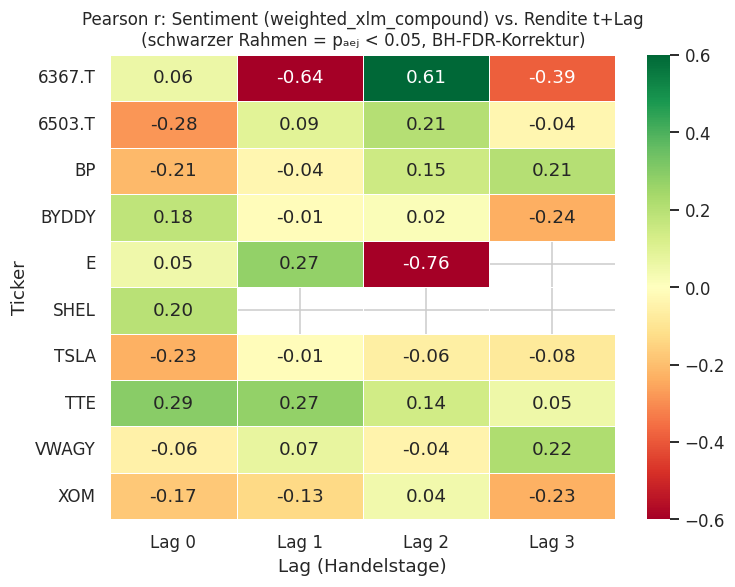

In [7]:
# ---------------------------------------------------------------------------
# 2b. Heatmap: Pearson r nach Ticker & Lag
# ---------------------------------------------------------------------------
if corr_df.empty:
    print("Keine Pearson-Heatmap: keine berechenbaren Korrelationen.")
else:
    heat = corr_df.pivot(index="ticker", columns="lag", values="pearson_r")
    heat.columns = [f"Lag {lag}" for lag in heat.columns]

    fig, ax = plt.subplots(figsize=(7, max(3, len(heat) * 0.55)))
    sns.heatmap(
        heat,
        annot=True,
        fmt=".2f",
        cmap="RdYlGn",
        center=0,
        vmin=-0.6,
        vmax=0.6,
        linewidths=0.5,
        ax=ax,
    )

    for y_idx, ticker in enumerate(heat.index):
        for x_idx, col in enumerate(heat.columns):
            lag_num = int(col.split()[-1])
            p_adj_val = corr_df.query("ticker == @ticker and lag == @lag_num")["pearson_p_adj"]
            if len(p_adj_val) and p_adj_val.values[0] < 0.05:
                ax.add_patch(plt.Rectangle((x_idx, y_idx), 1, 1, fill=False, edgecolor="black", lw=2))

    ax.set_title(
        "Pearson r: Sentiment (weighted_xlm_compound) vs. Rendite t+Lag\n"
        "(schwarzer Rahmen = p\u2090\u2091\u2c7c < 0.05, BH-FDR-Korrektur)",
        fontsize=11,
    )
    ax.set_ylabel("Ticker")
    ax.set_xlabel("Lag (Handelstage)")
    plt.tight_layout()
    _save_fig("01_pearson_heatmap_lags.png")
    plt.show()


## 3 — Rolling-Korrelation (30 Tage)

Zeigt, ob der Zusammenhang zwischen Sentiment und Rendite über die Zeit stabil ist
oder sich in Phasen hoher Marktvolatilität ändert.


Rolling skipped:
focus_ticker  aligned_days              rolling_reason
          BP            27 aligned_days<30 (actual=27)
         TTE            23 aligned_days<30 (actual=23)
      6503.T            17 aligned_days<30 (actual=17)
      6367.T            11 aligned_days<30 (actual=11)
           E             7  aligned_days<30 (actual=7)
        SHEL             5  aligned_days<30 (actual=5)
        CARR             3  aligned_days<30 (actual=3)
   NIBE-B.ST             1  aligned_days<30 (actual=1)

Saved figure -> ../report/figures/03_correlation_modeling/02_rolling_correlation.png


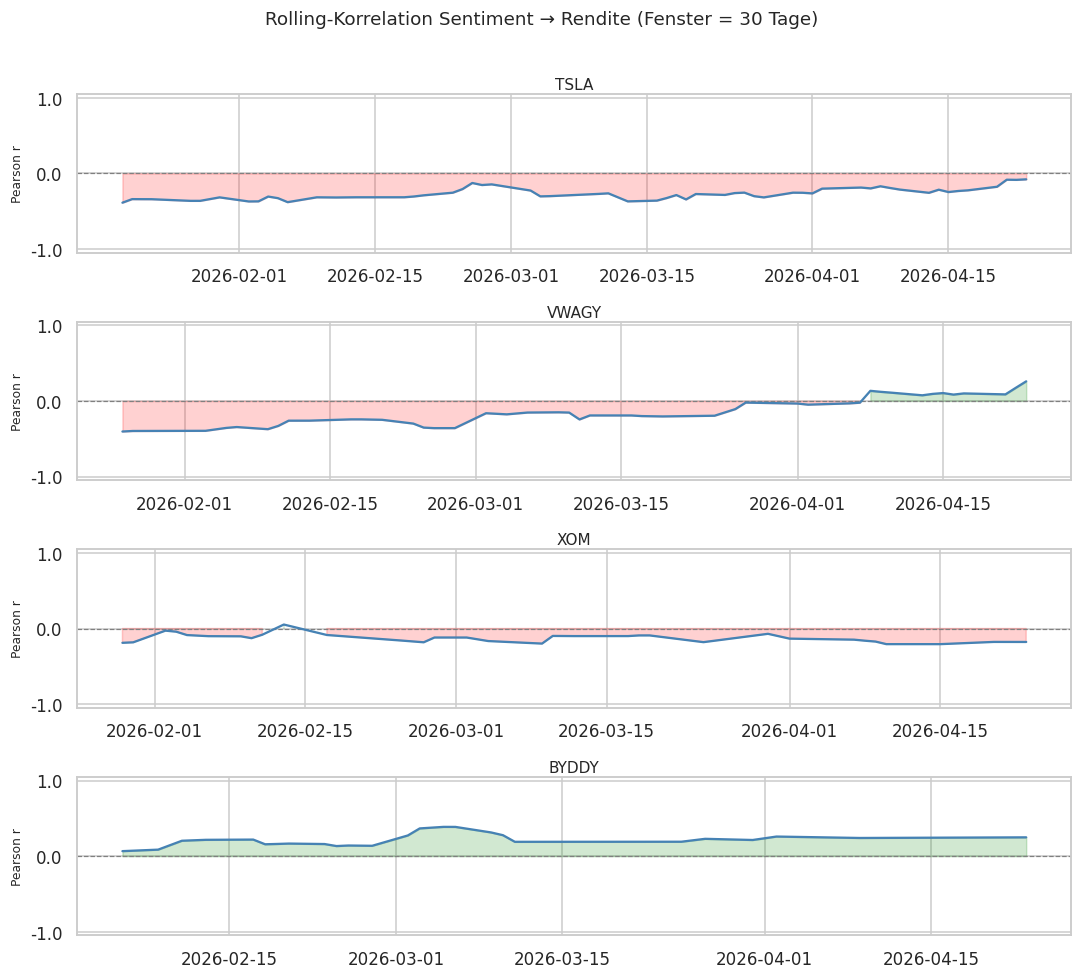

In [8]:
# ---------------------------------------------------------------------------
# 3. Rolling-Korrelation (Fenster = 30 Handelstage)
# ---------------------------------------------------------------------------
ROLL_TICK = overlap_df.loc[overlap_df["eligible_rolling"], "focus_ticker"].tolist()
rolling_skipped = overlap_df.loc[~overlap_df["eligible_rolling"], ["focus_ticker", "aligned_days", "rolling_reason"]]

if not rolling_skipped.empty:
    print("Rolling skipped:")
    print(rolling_skipped.to_string(index=False))
    print()

if not ROLL_TICK:
    print("Keine Ticker mit ausreichender Abdeckung für Rolling-Korrelation.")
else:
    fig, axes = plt.subplots(
        len(ROLL_TICK),
        1,
        figsize=(10, 2.2 * len(ROLL_TICK)),
        sharex=False,
    )
    if len(ROLL_TICK) == 1:
        axes = [axes]

    for ax, ticker in zip(axes, ROLL_TICK):
        grp = merged[merged["focus_ticker"] == ticker].set_index("date").sort_index()
        roll = grp[SENT_COL].rolling(ROLL_WIN, min_periods=ROLL_MIN).corr(grp["return"])
        ax.axhline(0, color="grey", lw=0.8, ls="--")
        ax.plot(roll.index, roll.values, lw=1.5, color="steelblue", label="Roll. Pearson r")
        ax.fill_between(roll.index, roll.values, 0, where=roll.values > 0, alpha=0.18, color="green")
        ax.fill_between(roll.index, roll.values, 0, where=roll.values < 0, alpha=0.18, color="red")
        ax.set_title(f"{ticker}", fontsize=10, pad=3)
        ax.set_ylim(-1.05, 1.05)
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
        ax.set_ylabel("Pearson r", fontsize=8)

    fig.suptitle(f"Rolling-Korrelation Sentiment → Rendite (Fenster = {ROLL_WIN} Tage)", fontsize=12, y=1.01)
    plt.tight_layout()
    _save_fig("02_rolling_correlation.png")
    plt.show()


## 4 — Granger-Kausalitätstest

Der Granger-Test prüft, ob **vergangenes Sentiment** die **zukünftige Rendite** besser
erklärt als die Rendite allein (und umgekehrt).  
Achtung: Granger-Kausalität ≠ echte Kausalität — es ist ein Vorhersage-Verbesserungstest.

Durchgeführt für Ticker mit ≥ 30 Beobachtungen.


In [9]:
# ---------------------------------------------------------------------------
# 4a. Stationaritätsprüfung (ADF-Test) – Voraussetzung für Granger-Test
# ---------------------------------------------------------------------------
adf_records = []
granger_eligible_tickers = overlap_df.loc[overlap_df["eligible_granger"], "focus_ticker"].tolist()

print("ADF-Test (H\u2080: Einheitswurzel = nicht stationär; p < 0.05 → stationär)")
print(f"{'Ticker':<12} {'Reihe':<26} {'ADF-Stat':>9} {'p-Wert':>8} {'Stationär':>10}")
print("-" * 70)

for ticker in granger_eligible_tickers:
    grp = merged[merged["focus_ticker"] == ticker].sort_values("date").dropna(subset=[SENT_COL, "return"])
    for series_name, series_data in [(SENT_COL, grp[SENT_COL]), ("return", grp["return"])]:
        try:
            adf_stat, adf_p, *_ = adfuller(series_data.values, autolag="AIC")
            is_stationary = adf_p < 0.05
            adf_records.append(dict(
                ticker=ticker, series=series_name,
                adf_stat=adf_stat, p_value=adf_p, is_stationary=is_stationary,
            ))
            marker = "\u2713" if is_stationary else "\u2717 WARNUNG"
            print(f"{ticker:<12} {series_name:<26} {adf_stat:>9.3f} {adf_p:>8.3f} {marker:>10}")
        except Exception as exc:
            logging.warning("%s ADF %s: %s", ticker, series_name, exc)

adf_df = pd.DataFrame(adf_records)

if not adf_df.empty:
    non_stationary = adf_df[~adf_df["is_stationary"]]
    print()
    if non_stationary.empty:
        print("Alle getesteten Reihen stationär (p < 0.05) → Granger-Voraussetzung erfüllt.")
    else:
        print("ACHTUNG: Möglicherweise nicht-stationäre Reihen (p \u2265 0.05):")
        print(non_stationary[["ticker", "series", "p_value"]].to_string(index=False))
        print("Granger-Ergebnisse für diese Ticker sind mit Vorsicht zu interpretieren.")


ADF-Test (H₀: Einheitswurzel = nicht stationär; p < 0.05 → stationär)
Ticker       Reihe                       ADF-Stat   p-Wert  Stationär
----------------------------------------------------------------------
TSLA         weighted_xlm_compound        -10.884    0.000          ✓
TSLA         return                        -4.366    0.000          ✓
VWAGY        weighted_xlm_compound         -6.162    0.000          ✓
VWAGY        return                        -8.587    0.000          ✓
XOM          weighted_xlm_compound         -5.938    0.000          ✓
XOM          return                        -4.977    0.000          ✓
BYDDY        weighted_xlm_compound         -6.204    0.000          ✓
BYDDY        return                        -7.056    0.000          ✓

Alle getesteten Reihen stationär (p < 0.05) → Granger-Voraussetzung erfüllt.


In [10]:
# ---------------------------------------------------------------------------
# 4. Granger-Kausalitätstest (maxlag = 3)
# ---------------------------------------------------------------------------
granger_records = []
granger_diag_records = []

for ticker in overlap_df["focus_ticker"]:
    grp = merged[merged["focus_ticker"] == ticker].sort_values("date").dropna(subset=[SENT_COL, "return"])
    eligible = len(grp) >= GRANGER_MIN
    reason = "eligible" if eligible else f"aligned_days<{GRANGER_MIN} (actual={len(grp)})"
    granger_diag_records.append(dict(ticker=ticker, aligned_days=len(grp), eligible=eligible, reason=reason))
    if not eligible:
        continue

    data_sr = grp[["return", SENT_COL]].values
    try:
        res_sr = grangercausalitytests(data_sr, maxlag=MAXLAG, verbose=False)
        for lag in range(1, MAXLAG + 1):
            p = res_sr[lag][0]["ssr_ftest"][1]
            granger_records.append(dict(ticker=ticker, direction="Sentiment→Rendite", lag=lag, p_value=p))
    except Exception as exc:
        logging.warning("%s Granger S→R: %s", ticker, exc)

    data_rs = grp[[SENT_COL, "return"]].values
    try:
        res_rs = grangercausalitytests(data_rs, maxlag=MAXLAG, verbose=False)
        for lag in range(1, MAXLAG + 1):
            p = res_rs[lag][0]["ssr_ftest"][1]
            granger_records.append(dict(ticker=ticker, direction="Rendite→Sentiment", lag=lag, p_value=p))
    except Exception as exc:
        logging.warning("%s Granger R→S: %s", ticker, exc)

granger_df = pd.DataFrame(granger_records)
granger_diag_df = pd.DataFrame(granger_diag_records)

print("Granger eligibility:")
print(granger_diag_df.to_string(index=False))

if not granger_df.empty:
    for direction in ["Sentiment→Rendite", "Rendite→Sentiment"]:
        sub = granger_df[granger_df["direction"] == direction].copy()
        piv = sub.pivot(index="ticker", columns="lag", values="p_value")
        piv.columns = [f"Lag {lag}" for lag in piv.columns]
        print(f"\nGranger p-Werte ({direction}):")
        styled = piv.map(lambda value: f"*{value:.3f}*" if value < 0.05 else f" {value:.3f} ")
        print(styled.to_string())
        print("  * p < 0.05")
else:
    eligible_n = int(granger_diag_df["eligible"].sum()) if not granger_diag_df.empty else 0
    if eligible_n == 0:
        print("Keine Ticker mit ausreichender Abdeckung für Granger-Test.")
    else:
        print("Granger-Test lief, aber es wurden keine Resultate erzeugt.")


Granger eligibility:
   ticker  aligned_days  eligible                      reason
     TSLA            68      True                    eligible
    VWAGY            53      True                    eligible
      XOM            41      True                    eligible
    BYDDY            34      True                    eligible
       BP            27     False aligned_days<30 (actual=27)
      TTE            23     False aligned_days<30 (actual=23)
   6503.T            17     False aligned_days<30 (actual=17)
   6367.T            11     False aligned_days<30 (actual=11)
        E             7     False  aligned_days<30 (actual=7)
     SHEL             5     False  aligned_days<30 (actual=5)
     CARR             3     False  aligned_days<30 (actual=3)
NIBE-B.ST             1     False  aligned_days<30 (actual=1)

Granger p-Werte (Sentiment→Rendite):
          Lag 1    Lag 2    Lag 3
ticker                           
BYDDY    0.901    0.918    0.757 
TSLA     0.957    0.658    0.602 

Saved figure -> ../report/figures/03_correlation_modeling/03_granger_heatmaps.png


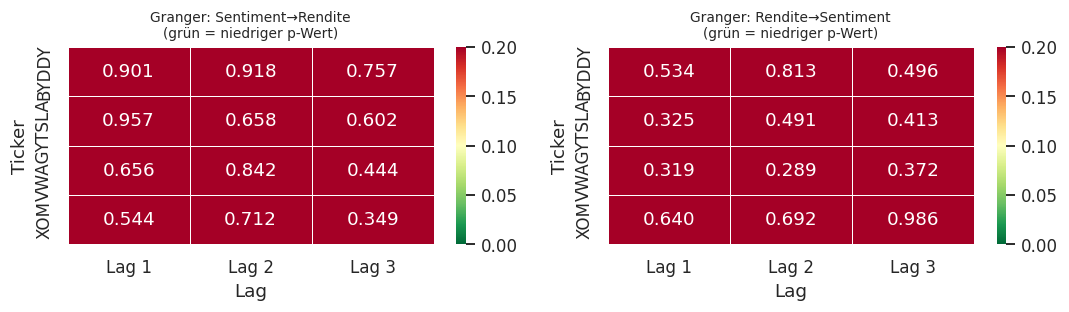

In [11]:
# ---------------------------------------------------------------------------
# 4b. Granger p-Wert Heatmap (beide Richtungen)
# ---------------------------------------------------------------------------
if granger_df.empty:
    print("Keine Granger-Heatmap: keine berechenbaren Tests.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(10, max(3, granger_df["ticker"].nunique() * 0.6)))
    for ax, direction in zip(axes, ["Sentiment→Rendite", "Rendite→Sentiment"]):
        sub = granger_df[granger_df["direction"] == direction]
        piv = sub.pivot(index="ticker", columns="lag", values="p_value")
        piv.columns = [f"Lag {lag}" for lag in piv.columns]
        sns.heatmap(
            piv,
            annot=True,
            fmt=".3f",
            cmap="RdYlGn_r",
            vmin=0,
            vmax=0.2,
            linewidths=0.5,
            ax=ax,
        )
        ax.set_title(f"Granger: {direction}\n(grün = niedriger p-Wert)", fontsize=9)
        ax.set_ylabel("Ticker")
        ax.set_xlabel("Lag")
    plt.tight_layout()
    _save_fig("03_granger_heatmaps.png")
    plt.show()


## 5 — Event-Study: Renditen um extreme Sentiment-Tage

Wir identifizieren Tage, an denen der Sentiment-Score deutlich vom Ticker-Mittelwert
abweicht (> 1 Standardabweichung), und analysieren die **kumulativen abnormalen Renditen (CAR)**
in einem Fenster von ±5 Handelstagen um das Ereignis.


In [12]:
# ---------------------------------------------------------------------------
# 5. Event-Study
# ---------------------------------------------------------------------------
# ── S&P 500 als externer Marktbenchmark (ersetzt internen Focus-Ticker-Mittelwert)
spx_start = (merged["date"].min() - pd.Timedelta(days=5)).strftime("%Y-%m-%d")
spx_end = (merged["date"].max() + pd.Timedelta(days=2)).strftime("%Y-%m-%d")
try:
    spx_raw = yf.download("^GSPC", start=spx_start, end=spx_end, auto_adjust=True, progress=False)
    # Handle MultiIndex columns (yfinance >= 0.2.x)
    if isinstance(spx_raw.columns, pd.MultiIndex):
        spx_close = spx_raw[("Close", "^GSPC")]
    else:
        spx_close = spx_raw["Close"]
    spx_close.index = pd.to_datetime(spx_close.index).normalize()
    market_ret = (
        spx_close.pct_change()
        .rename("market_return")
        .reset_index()
        .rename(columns={"Date": "date", "index": "date"})
    )
    market_ret["date"] = pd.to_datetime(market_ret["date"])
    print(f"S&P 500 Benchmark geladen: {len(market_ret)} Handelstage ({spx_start} \u2192 {spx_end})")
except Exception as exc:
    logging.warning("S&P 500-Daten nicht verfügbar (%s) \u2013 Fallback auf Focus-Ticker-Mittelwert", exc)
    market_ret = (
        merged.groupby("date")["return"]
        .mean()
        .rename("market_return")
        .reset_index()
    )
    print("Fallback: Focus-Ticker-Mittelwert als Benchmark")

merged2 = merged.merge(market_ret[["date", "market_return"]], on="date", how="left")
merged2["abnormal_return"] = merged2["return"] - merged2["market_return"]

event_records = []
event_diag_records = []

for ticker in overlap_df["focus_ticker"]:
    grp = merged2[merged2["focus_ticker"] == ticker].sort_values("date").reset_index(drop=True)
    aligned_n = len(grp)
    if aligned_n < EVENT_BASE_MIN_ROWS:
        event_diag_records.append(dict(
            ticker=ticker,
            aligned_days=aligned_n,
            sentiment_std=np.nan,
            positive_events=0,
            negative_events=0,
            eligible_event=False,
            reason=f"aligned_days<{EVENT_BASE_MIN_ROWS} (actual={aligned_n})",
        ))
        continue

    mu = grp[SENT_COL].mean()
    sd = grp[SENT_COL].std()
    if pd.isna(sd) or sd == 0:
        event_diag_records.append(dict(
            ticker=ticker,
            aligned_days=aligned_n,
            sentiment_std=sd,
            positive_events=0,
            negative_events=0,
            eligible_event=False,
            reason="sentiment_std==0",
        ))
        continue

    pos_mask = grp[SENT_COL] > mu + SPIKE_STD * sd
    neg_mask = grp[SENT_COL] < mu - SPIKE_STD * sd
    pos_idx = grp.index[pos_mask].tolist()
    neg_idx = grp.index[neg_mask].tolist()

    eligible_event = len(pos_idx) >= EVENT_MIN or len(neg_idx) >= EVENT_MIN
    reason = "eligible" if eligible_event else f"events<{EVENT_MIN} (pos={len(pos_idx)}, neg={len(neg_idx)})"
    event_diag_records.append(dict(
        ticker=ticker,
        aligned_days=aligned_n,
        sentiment_std=sd,
        positive_events=len(pos_idx),
        negative_events=len(neg_idx),
        eligible_event=eligible_event,
        reason=reason,
    ))

    for direction, event_idx in [("Positiv", pos_idx), ("Negativ", neg_idx)]:
        if len(event_idx) < EVENT_MIN:
            continue

        car_windows = []
        for idx in event_idx:
            lo = max(0, idx - WINDOW)
            hi = min(len(grp) - 1, idx + WINDOW)
            window_data = grp.loc[lo:hi, ["date", "abnormal_return"]].copy()
            window_data["t"] = range(lo - idx, hi - idx + 1)
            car_windows.append(window_data)

        if not car_windows:
            continue

        combined = pd.concat(car_windows)
        avg_ar = combined.groupby("t")["abnormal_return"].mean()
        for t, ar in avg_ar.items():
            event_records.append(dict(
                ticker=ticker,
                direction=direction,
                t=t,
                avg_abnormal_return=ar,
                n_events=len(event_idx),
            ))

event_df = pd.DataFrame(event_records)
event_diag_df = pd.DataFrame(event_diag_records)

print("Event-study eligibility:")
print(event_diag_df.to_string(index=False))
print()
if not event_df.empty:
    tickers_with_events = event_df["ticker"].unique()
    print(f"Event-Study: {len(tickers_with_events)} Ticker mit ausreichend Events")
    for ticker in tickers_with_events:
        sub = event_df[event_df["ticker"] == ticker]
        pos_n = sub.loc[sub["direction"] == "Positiv", "n_events"]
        neg_n = sub.loc[sub["direction"] == "Negativ", "n_events"]
        print(f"  {ticker}: {int(pos_n.iloc[0]) if not pos_n.empty else 0} positive Events, {int(neg_n.iloc[0]) if not neg_n.empty else 0} negative Events")
else:
    print("Keine Ticker mit ausreichend Events für die Event-Study.")


S&P 500 Benchmark geladen: 81 Handelstage (2025-12-28 → 2026-04-25)
Event-study eligibility:
   ticker  aligned_days  sentiment_std  positive_events  negative_events  eligible_event                      reason
     TSLA            68       0.352197               11                9            True                    eligible
    VWAGY            53       0.440785                5                9            True                    eligible
      XOM            41       0.385116                8                8            True                    eligible
    BYDDY            34       0.343095                6                5            True                    eligible
       BP            27       0.327173                4                5            True                    eligible
      TTE            23       0.459559                5                3            True                    eligible
   6503.T            17            NaN                0                0           False

Saved figure -> ../report/figures/03_correlation_modeling/04_event_study_car.png


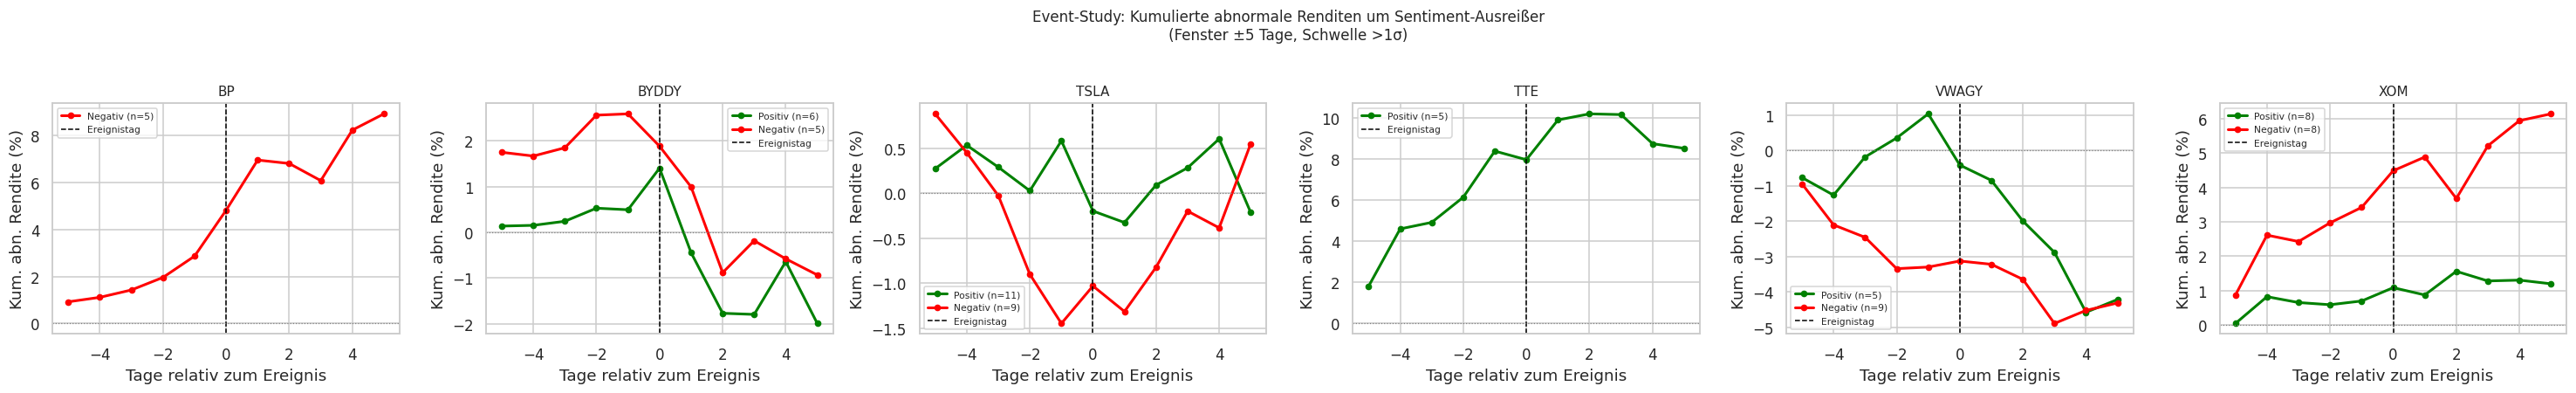

In [13]:
# ---------------------------------------------------------------------------
# 5b. Event-Study Plot (CAR ±WINDOW Tage)
# ---------------------------------------------------------------------------
if not event_df.empty:
    tickers_with_events = sorted(event_df["ticker"].unique())
    n_tickers = len(tickers_with_events)
    fig, axes = plt.subplots(
        1, n_tickers, figsize=(4.5 * n_tickers, 4),
        sharey=False
    )
    if n_tickers == 1:
        axes = [axes]

    for ax, ticker in zip(axes, tickers_with_events):
        sub = event_df[event_df["ticker"] == ticker]
        for direction, color in [("Positiv", "green"), ("Negativ", "red")]:
            d = sub[sub["direction"] == direction].sort_values("t")
            if d.empty:
                continue
            n_ev = d["n_events"].iloc[0]
            cum = d.set_index("t")["avg_abnormal_return"].cumsum()
            ax.plot(cum.index, cum.values * 100,
                    color=color, lw=2, marker="o", ms=4,
                    label=f"{direction} (n={n_ev})")
        ax.axvline(0, color="black", ls="--", lw=1, label="Ereignistag")
        ax.axhline(0, color="grey",  ls=":",  lw=0.8)
        ax.set_title(ticker, fontsize=10)
        ax.set_xlabel("Tage relativ zum Ereignis")
        ax.set_ylabel("Kum. abn. Rendite (%)")
        ax.legend(fontsize=7)

    fig.suptitle(f"Event-Study: Kumulierte abnormale Renditen um Sentiment-Ausreißer\n"
                 f"(Fenster ±{WINDOW} Tage, Schwelle >{SPIKE_STD:.0f}σ)",
                 fontsize=11, y=1.02)
    plt.tight_layout()
    _save_fig("04_event_study_car.png")
    plt.show()
else:
    print("Keine Event-Study-Daten vorhanden.")


## 6 — Ergebnis speichern


In [14]:
# ---------------------------------------------------------------------------
# 6. Ergebnisse speichern
# ---------------------------------------------------------------------------
corr_out_path = OUT_DIR / "correlation_results.parquet"
granger_out_path = OUT_DIR / "granger_results.parquet"
event_out_path = OUT_DIR / "event_study_results.parquet"

overlap_report = overlap_df.copy()
if not corr_coverage_df.empty:
    corr_summary = corr_coverage_df.groupby("ticker").agg(
        corr_max_n=("n", "max"),
        corr_eligible_lags=("eligible", "sum"),
    ).reset_index().rename(columns={"ticker": "focus_ticker"})
    overlap_report = overlap_report.merge(corr_summary, on="focus_ticker", how="left")

if 'granger_diag_df' in globals() and not granger_diag_df.empty:
    overlap_report = overlap_report.merge(
        granger_diag_df.rename(columns={"ticker": "focus_ticker", "eligible": "granger_ran", "reason": "granger_run_reason"}),
        on="focus_ticker",
        how="left",
    )

if 'event_diag_df' in globals() and not event_diag_df.empty:
    overlap_report = overlap_report.merge(
        event_diag_df.rename(columns={"ticker": "focus_ticker", "reason": "event_run_reason"}),
        on="focus_ticker",
        how="left",
    )

overlap_report.to_parquet(OVERLAP_OUT_PATH, index=False)
print(f"Saved overlap_report       → {OVERLAP_OUT_PATH}  ({len(overlap_report)} rows)")

corr_df.to_parquet(corr_out_path, index=False)
print(f"Saved correlation_results  → {corr_out_path}  ({len(corr_df)} rows)")

if not granger_df.empty:
    granger_df.to_parquet(granger_out_path, index=False)
    print(f"Saved granger_results      → {granger_out_path}  ({len(granger_df)} rows)")

if not event_df.empty:
    event_df.to_parquet(event_out_path, index=False)
    print(f"Saved event_study_results  → {event_out_path}  ({len(event_df)} rows)")


Saved overlap_report       → ../data/processed/overlap_report.parquet  (12 rows)
Saved correlation_results  → ../data/processed/correlation_results.parquet  (36 rows)
Saved granger_results      → ../data/processed/granger_results.parquet  (24 rows)
Saved event_study_results  → ../data/processed/event_study_results.parquet  (110 rows)


## 7 — Zusammenfassung der Ergebnisse


In [15]:
# ---------------------------------------------------------------------------
# 7. Zusammenfassung
# ---------------------------------------------------------------------------
lines = [
    "### Korrelationsmodellierung — Kernbefunde\n",
    "",
    "| Metrik | Wert |",
    "|--------|------|",
    f"| Primärinput | `{DAILY_PATH.name}` |",
    f"| Ticker im Sentiment-Input | {len(overlap_report)} |",
    f"| Ticker mit Aligned Days > 0 | {(overlap_report['aligned_days'] > 0).sum()} |",
    f"| Aligned Datenpunkte | {len(merged)} |",
    f"| Überlappungszeitraum | {merged['date'].min().date()} → {merged['date'].max().date()} |" if not merged.empty else "| Überlappungszeitraum | n/a |",
    f"| Sentiment-Signal | `{SENT_COL}` |",
    "| Retweets in NB03 | ausgeschlossen (Primäranalyse = Original-Tweets) |",
    "| Multiple-Testing-Korrektur | BH-FDR (Benjamini-Hochberg) |",
    "| Event-Study-Benchmark | S&P 500 (^GSPC) |",
    "",
    "**Overlap pro Ticker:**",
    "",
    "| Ticker | Aligned Days | Corr | Rolling | Granger | Event-Basis |",
    "|--------|--------------|------|---------|---------|-------------|",
]

for _, row in overlap_report.sort_values("aligned_days", ascending=False).iterrows():
    lines.append(
        f"| {row['focus_ticker']} | {int(row['aligned_days'])} | "
        f"{'✓' if bool(row['eligible_corr']) else '✗'} | "
        f"{'✓' if bool(row['eligible_rolling']) else '✗'} | "
        f"{'✓' if bool(row['eligible_granger']) else '✗'} | "
        f"{'✓' if bool(row['eligible_event_base']) else '✗'} |"
    )

if not corr_df.empty:
    best = corr_df.loc[corr_df.groupby("ticker")["pearson_r"].apply(lambda x: x.abs().idxmax())]
    best = best.sort_values("pearson_r", key=abs, ascending=False)
    lines.extend([
        "",
        "**Stärkste Lag-Korrelationen (Pearson r, nach BH-FDR-Korrektur):**",
        "",
        "| Ticker | Bester Lag | Pearson r | 95%-KI | p_raw | p_adj | n |",
        "|--------|-----------|-----------|--------|-------|-------|---|",
    ])
    for _, row in best.iterrows():
        sig = "✓" if row.get("pearson_significant", False) else ""
        ci_lo = f"{row['pearson_ci_lo']:.3f}" if not pd.isna(row.get("pearson_ci_lo", float("nan"))) else "n/a"
        ci_hi = f"{row['pearson_ci_hi']:.3f}" if not pd.isna(row.get("pearson_ci_hi", float("nan"))) else "n/a"
        p_adj_str = f"{row['pearson_p_adj']:.3f}" if not pd.isna(row.get("pearson_p_adj", float("nan"))) else "n/a"
        lines.append(
            f"| {row['ticker']} | Lag {int(row['lag'])} | {row['pearson_r']:+.3f} {sig} | "
            f"[{ci_lo}, {ci_hi}] | {row['pearson_p']:.3f} | {p_adj_str} | {int(row['n'])} |"
        )
else:
    lines.extend(["", "Keine Pearson/Spearman-Resultate berechenbar."])

lines.append("")
if not granger_df.empty:
    sig_granger = granger_df[granger_df["p_value"] < 0.05]
    if sig_granger.empty:
        lines.append("**Granger-Kausalität:** Keine signifikanten Resultate (p < 0.05).")
    else:
        lines.append(f"**Granger-Kausalität:** {len(sig_granger)} signifikante Ticker×Lag×Richtung-Kombinationen (p < 0.05).")
else:
    eligible_granger = int(overlap_report['eligible_granger'].sum())
    if eligible_granger == 0:
        lines.append("**Granger-Kausalität:** Kein Ticker erreichte die Mindestabdeckung.")
    else:
        lines.append("**Granger-Kausalität:** Keine auswertbaren Resultate trotz formaler Eligibility.")

if not event_df.empty:
    event_tickers = event_df["ticker"].nunique()
    lines.append(f"**Event-Study:** {event_tickers} Ticker mit ausreichender Event-Zahl (Benchmark: S&P 500).")
else:
    eligible_event = int(event_diag_df['eligible_event'].sum()) if 'event_diag_df' in globals() and not event_diag_df.empty else 0
    if eligible_event == 0:
        lines.append("**Event-Study:** Kein Ticker erreichte die erforderliche Event-Zahl.")
    else:
        lines.append("**Event-Study:** Eligibility vorhanden, aber keine speicherbaren Event-Resultate erzeugt.")

summary_md = "\n".join(lines)
from IPython.display import Markdown, display
display(Markdown(summary_md))


### Korrelationsmodellierung — Kernbefunde


| Metrik | Wert |
|--------|------|
| Primärinput | `daily_sentiment_original.parquet` |
| Ticker im Sentiment-Input | 12 |
| Ticker mit Aligned Days > 0 | 12 |
| Aligned Datenpunkte | 290 |
| Überlappungszeitraum | 2026-01-02 → 2026-04-23 |
| Sentiment-Signal | `weighted_xlm_compound` |
| Retweets in NB03 | ausgeschlossen (Primäranalyse = Original-Tweets) |
| Multiple-Testing-Korrektur | BH-FDR (Benjamini-Hochberg) |
| Event-Study-Benchmark | S&P 500 (^GSPC) |

**Overlap pro Ticker:**

| Ticker | Aligned Days | Corr | Rolling | Granger | Event-Basis |
|--------|--------------|------|---------|---------|-------------|
| TSLA | 68 | ✓ | ✓ | ✓ | ✓ |
| VWAGY | 53 | ✓ | ✓ | ✓ | ✓ |
| XOM | 41 | ✓ | ✓ | ✓ | ✓ |
| BYDDY | 34 | ✓ | ✓ | ✓ | ✓ |
| BP | 27 | ✓ | ✗ | ✗ | ✓ |
| TTE | 23 | ✓ | ✗ | ✗ | ✓ |
| 6503.T | 17 | ✓ | ✗ | ✗ | ✗ |
| 6367.T | 11 | ✓ | ✗ | ✗ | ✗ |
| E | 7 | ✓ | ✗ | ✗ | ✗ |
| SHEL | 5 | ✓ | ✗ | ✗ | ✗ |
| CARR | 3 | ✗ | ✗ | ✗ | ✗ |
| NIBE-B.ST | 1 | ✗ | ✗ | ✗ | ✗ |

**Stärkste Lag-Korrelationen (Pearson r, nach BH-FDR-Korrektur):**

| Ticker | Bester Lag | Pearson r | 95%-KI | p_raw | p_adj | n |
|--------|-----------|-----------|--------|-------|-------|---|
| E | Lag 2 | -0.762  | [-0.983, 0.367] | 0.134 | 0.830 | 5 |
| 6367.T | Lag 1 | -0.636  | [-0.904, -0.011] | 0.048 | 0.830 | 10 |
| TTE | Lag 0 | +0.294  | [-0.135, 0.630] | 0.174 | 0.830 | 23 |
| 6503.T | Lag 0 | -0.283  | [-0.672, 0.229] | 0.272 | 0.830 | 17 |
| BYDDY | Lag 3 | -0.237  | [-0.546, 0.128] | 0.198 | 0.830 | 31 |
| TSLA | Lag 0 | -0.234  | [-0.447, 0.005] | 0.055 | 0.830 | 68 |
| XOM | Lag 3 | -0.232  | [-0.513, 0.095] | 0.162 | 0.830 | 38 |
| VWAGY | Lag 3 | +0.220  | [-0.062, 0.469] | 0.125 | 0.830 | 50 |
| BP | Lag 0 | -0.212  | [-0.548, 0.183] | 0.289 | 0.830 | 27 |
| SHEL | Lag 0 | +0.196  | [-0.830, 0.919] | 0.752 | 0.952 | 5 |

**Granger-Kausalität:** Keine signifikanten Resultate (p < 0.05).
**Event-Study:** 6 Ticker mit ausreichender Event-Zahl (Benchmark: S&P 500).